In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

file_path = r"C:\Users\chinm\Downloads\creditcard.csv.zip"

if os.path.exists(file_path):
    os.remove(file_path)
    print("Old file deleted successfully!")
else:
    print("Old file not found.")

Old file not found.


In [3]:
from google.colab import files

uploaded = files.upload()


Saving creditcard.csv.zip to creditcard.csv.zip


In [4]:
file_name = list(uploaded.keys())[0]
file_path = "/content/" + file_name

print("Your file:", file_name)
print("Your path:", file_path)

Your file: creditcard.csv.zip
Your path: /content/creditcard.csv.zip


In [5]:
import os

print("Files in Colab:")

for file in os.listdir("/content"):
    print(file)

Files in Colab:
.config
creditcard.csv.zip
sample_data


In [6]:
import zipfile
import os

file_path = "/content/creditcard.csv.zip"

print("File exists:", os.path.exists(file_path))
print("Valid ZIP:", zipfile.is_zipfile(file_path))

File exists: True
Valid ZIP: True


In [7]:
extract_path = "/content/creditcard_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(file_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction successful!")
print(os.listdir(extract_path))

Extraction successful!
['creditcard.csv']


In [8]:
import pandas as pd
import os

print("Extracted files:")

for root, dirs, files_list in os.walk("/content/creditcard_data"):
    for file in files_list:
        print(os.path.join(root, file))

Extracted files:
/content/creditcard_data/creditcard.csv


In [9]:
df = pd.read_csv("/content/creditcard_data/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head(10)

Dataset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [10]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [13]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1081


In [16]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


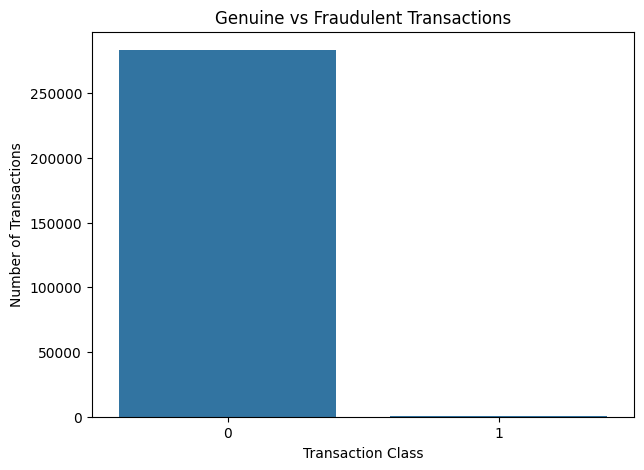

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(x='Class', data=df)

plt.title("Genuine vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [18]:
class_counts = df['Class'].value_counts()

print(class_counts)

Class
0    283253
1       473
Name: count, dtype: int64


In [19]:
class_percentage = df['Class'].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


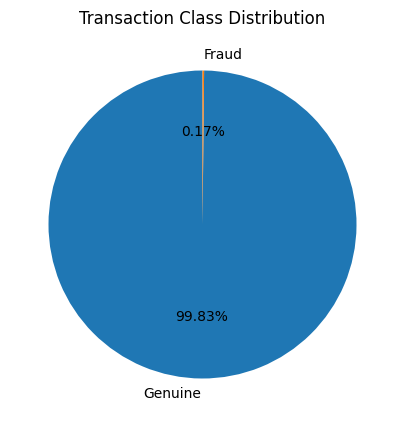

In [20]:
plt.figure(figsize=(7,5))

plt.pie(
    class_counts,
    labels=['Genuine', 'Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Transaction Class Distribution")

plt.show()

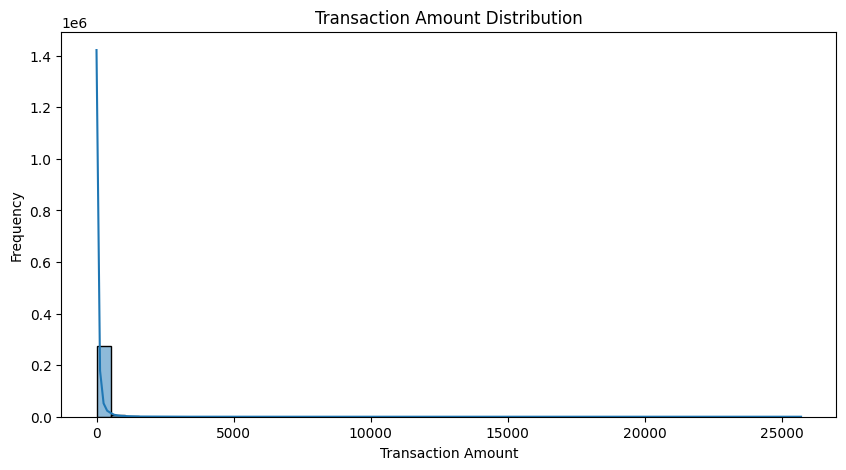

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

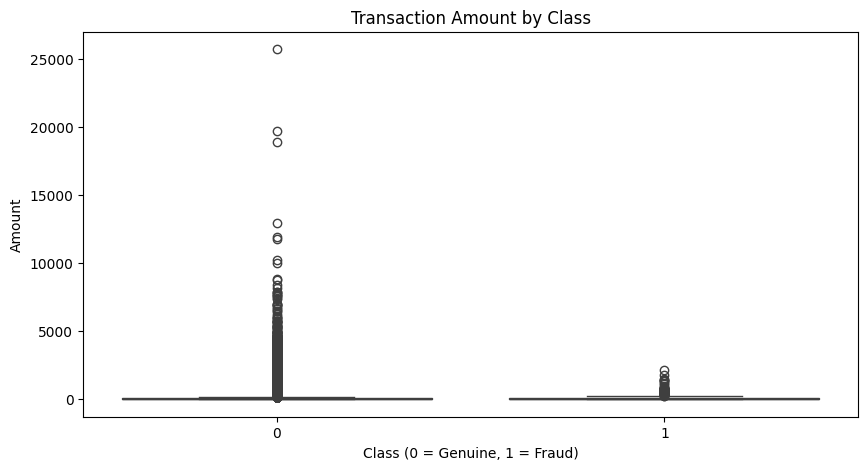

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

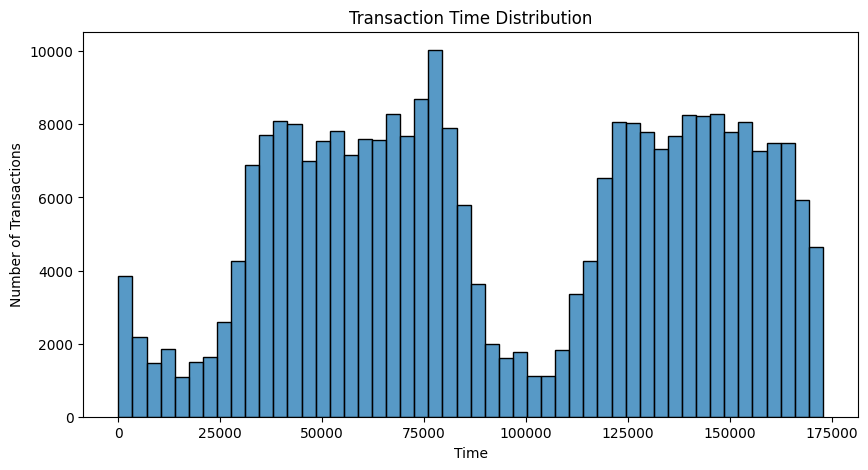

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

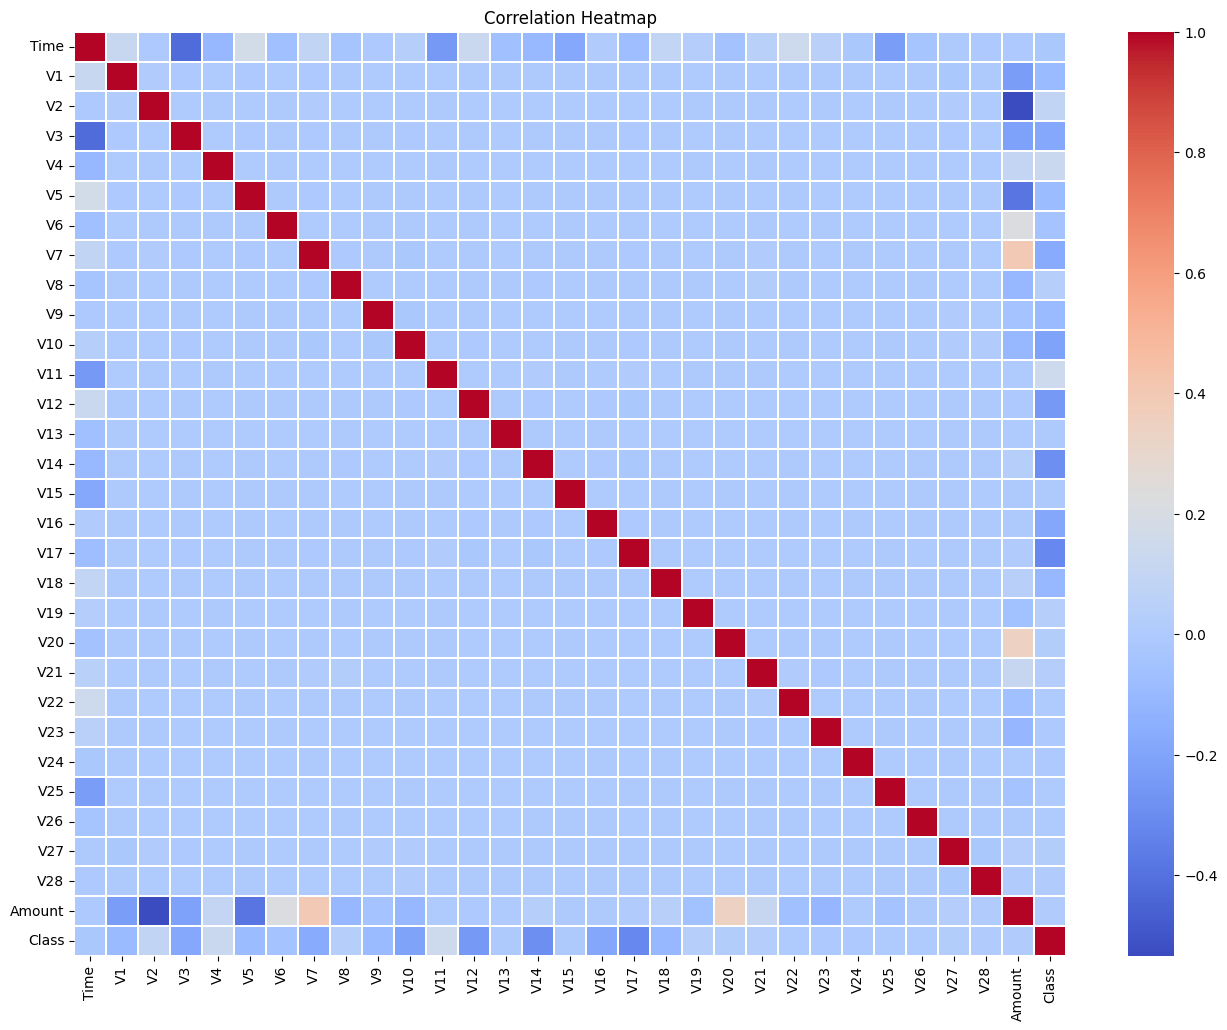

In [24]:
plt.figure(figsize=(16,12))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.1
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
class_correlation = df.corr()['Class'].sort_values()

print(class_correlation)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64


In [26]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (226980, 30)
Testing data: (56746, 30)


In [28]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [30]:
scaler.fit_transform(X_train)

array([[ 1.04549909,  1.14719836, -1.04203246, ...,  0.09278213,
        -0.15619266, -0.22943372],
       [-0.29869002, -0.67791131,  0.99194846, ..., -0.04986389,
         0.15383143, -0.33119698],
       [ 0.67839667,  0.97765362,  0.0162054 , ...,  0.11132947,
        -0.16581986, -0.29880852],
       ...,
       [ 1.19385202, -0.45214212,  0.70655379, ..., -0.62638332,
         0.28835592, -0.20908921],
       [-0.95824459,  0.63781446,  0.21468286, ...,  0.10812079,
         0.09533138, -0.3392941 ],
       [-0.89610272,  0.52361687, -0.13216317, ...,  0.1416972 ,
        -0.0070969 , -0.30955042]])

In [31]:
scaler.transform(X_test)

array([[-0.70776084,  0.62846035, -0.03507436, ...,  0.00334824,
         0.00256256, -0.31284623],
       [ 1.27387205, -0.10690835,  0.71666883, ...,  0.96769184,
         0.79940005, -0.35174494],
       [-1.34811061, -0.86164079,  0.85283366, ...,  0.01560762,
         0.34674777,  0.01177083],
       ...,
       [-0.44196799,  0.60372332, -0.11740337, ...,  0.02988069,
         0.07761042, -0.32244884],
       [ 0.68907303,  1.05584343,  0.08623043, ..., -0.16707329,
        -0.13668677, -0.35601729],
       [-1.76535189,  0.63786439,  0.04036693, ..., -0.21956371,
         0.02075116, -0.29473961]])

In [32]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


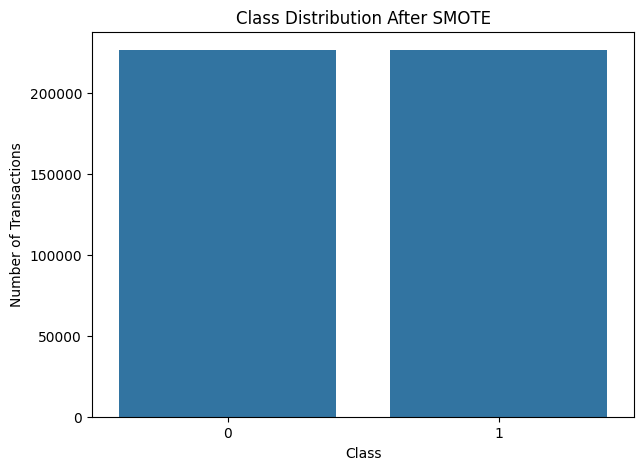

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [34]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [35]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [36]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)
print("ROC-AUC  :", roc_auc_lr)

Logistic Regression Results
--------------------------------
Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1
ROC-AUC  : 0.9626184886409772


In [37]:
print("Classification Report - Logistic Regression")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Genuine', 'Fraud']
    )
)

Classification Report - Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



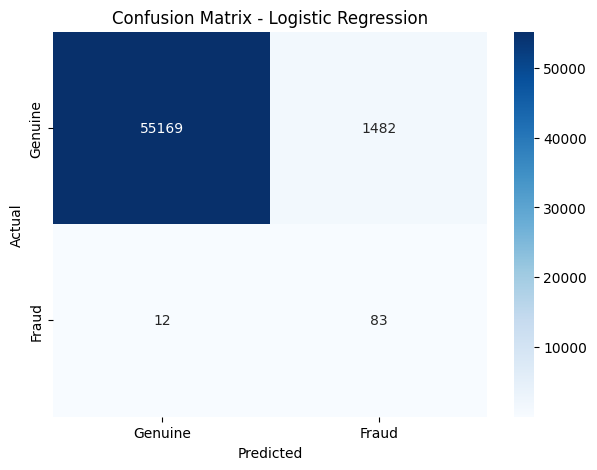

In [38]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train_scaled, y_train)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [40]:
print("Number of trees:", len(rf_model.estimators_))

Number of trees: 50


In [41]:
y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed!")

Prediction completed!


In [42]:
y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [43]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Random Forest Results
--------------------------------
Accuracy : 0.9994713283755683
Precision: 0.9333333333333333
Recall   : 0.7368421052631579
F1 Score : 0.8235294117647058
ROC-AUC  : 0.9391300752808749


In [44]:
print("Classification Report - Random Forest")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Genuine', 'Fraud']
    )
)

Classification Report - Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.93      0.74      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



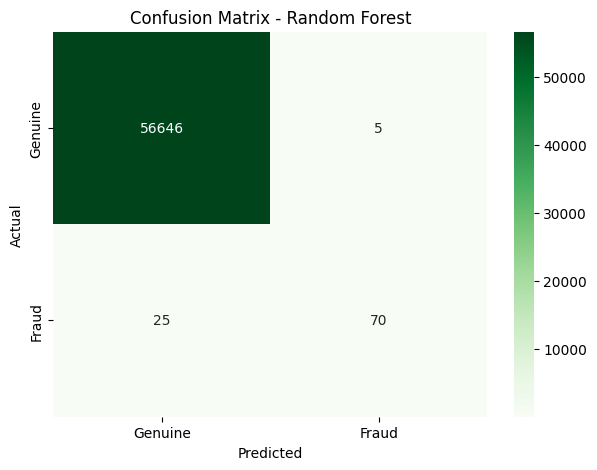

In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_rf
    ],

    'Precision': [
        precision_lr,
        precision_rf
    ],

    'Recall': [
        recall_lr,
        recall_rf
    ],

    'F1 Score': [
        f1_lr,
        f1_rf
    ],

    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.962618
1,Random Forest,0.999471,0.933333,0.736842,0.823529,0.939130


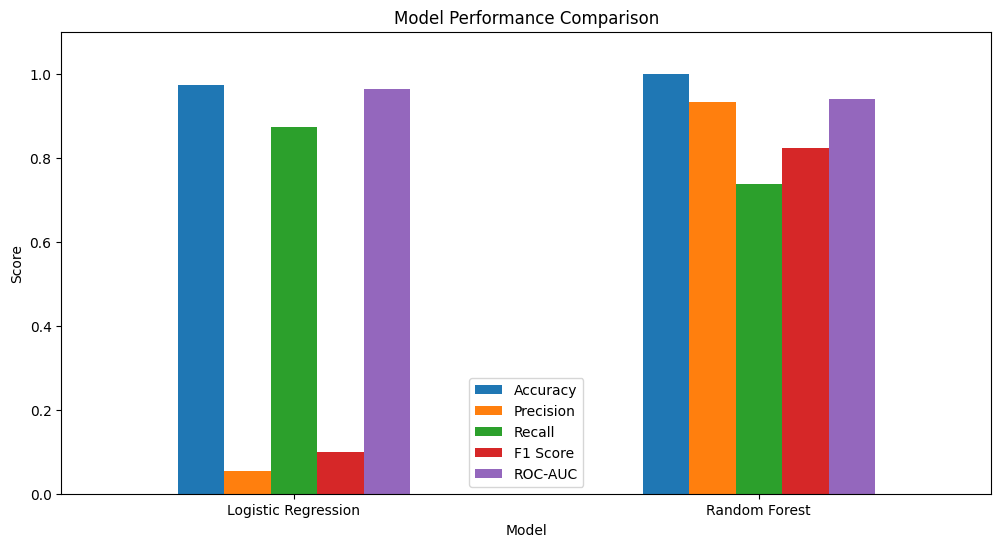

In [47]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)

plt.show()

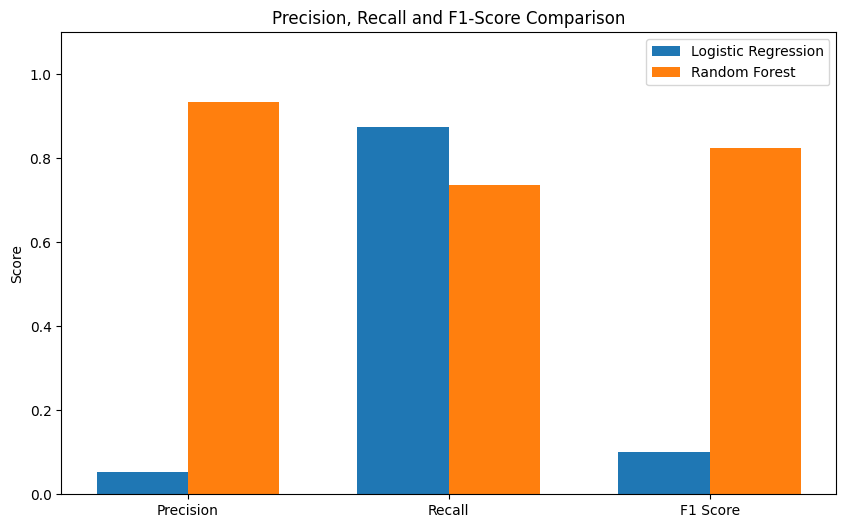

In [48]:
metrics = ['Precision', 'Recall', 'F1 Score']

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    [precision_lr, recall_lr, f1_lr],
    width,
    label='Logistic Regression'
)

plt.bar(
    x + width/2,
    [precision_rf, recall_rf, f1_rf],
    width,
    label='Random Forest'
)

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score Comparison")

plt.legend()
plt.ylim(0, 1.1)

plt.show()

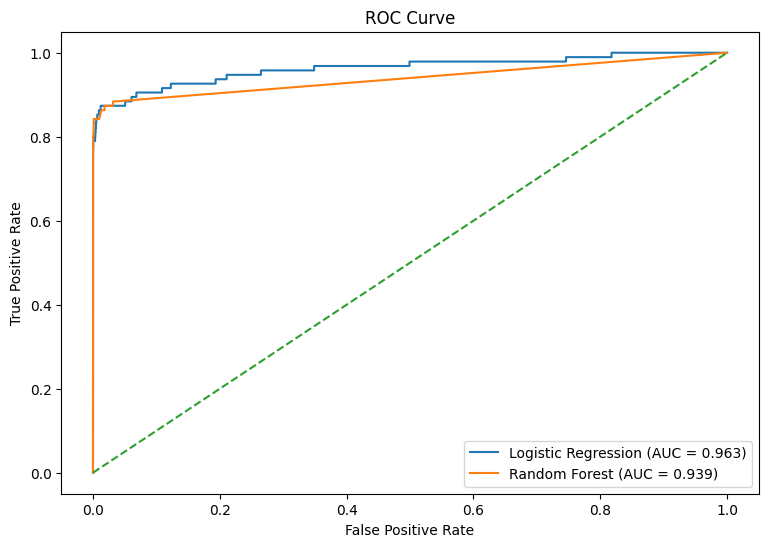

In [49]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(9,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_rf:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [50]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.275871
10,V10,0.103908
17,V17,0.088882
4,V4,0.088509
3,V3,0.078662
12,V12,0.074470
16,V16,0.062222
2,V2,0.025632
9,V9,0.020702
27,V27,0.018883


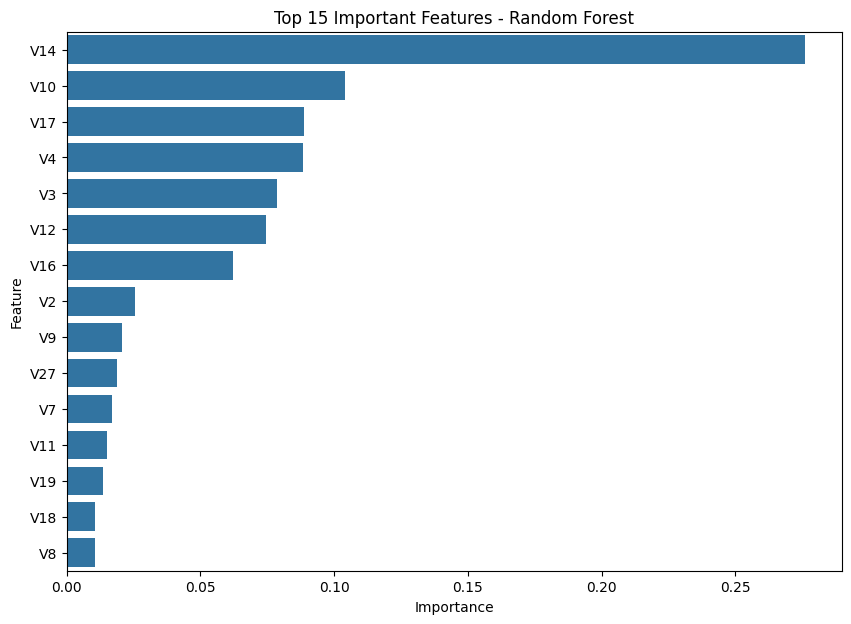

In [51]:
plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features - Random Forest")

plt.show()

In [52]:
best_model = results.loc[
    results['F1 Score'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Random Forest
Accuracy          0.999471
Precision         0.933333
Recall            0.736842
F1 Score          0.823529
ROC-AUC            0.93913
Name: 1, dtype: object


In [53]:
import joblib

joblib.dump(
    rf_model,
    "credit_card_fraud_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [54]:
loaded_model = joblib.load(
    "credit_card_fraud_model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [55]:
# Example:
# Replace these values with a real transaction's feature values

new_transaction = X.iloc[0].values.reshape(1, -1)

new_transaction_scaled = loaded_scaler.transform(
    new_transaction
)

prediction = loaded_model.predict(
    new_transaction_scaled
)

if prediction[0] == 1:
    print("Fraudulent Transaction")
else:
    print("Genuine Transaction")

Genuine Transaction
